In [1]:
!python -V

python(79844) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Python 3.12.1


In [2]:
import gc
# import ML deps
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from hyperopt.pyll import scope


from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [3]:
# set ML experiment tracking
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
# mlflow.set_experiment('demo-experiment-nyc-taxi-pred')
mlflow.set_experiment('ride-duration-prediction-xgboost')

<Experiment: artifact_location='/Users/ikwang/Documents/Projects/learning-MLOps/mlops-zoomcamp/mlruns/2', creation_time=1786416581956, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1786416581956, lifecycle_stage='active', name='ride-duration-prediction-xgboost', tags={}, trace_location=None, workspace='default'>

In [34]:
# ingest & read data
df = pd.read_parquet('./data/green_tripdata_2026-01.parquet')

In [35]:
# inspect data
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


#### modelling #1

In [23]:
# data prep
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [ ]:
# feature selection
train_dicts = df[categorical + numerical].to_dict(orient='records')
target = 'duration'

# set train set 
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
y_train = df[target].values

# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_train)

# eval
root_mean_squared_error(y_train, y_pred)

8.048606200417199

/tmp/ipykernel_19170/1196719062.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_19170/1196719062.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


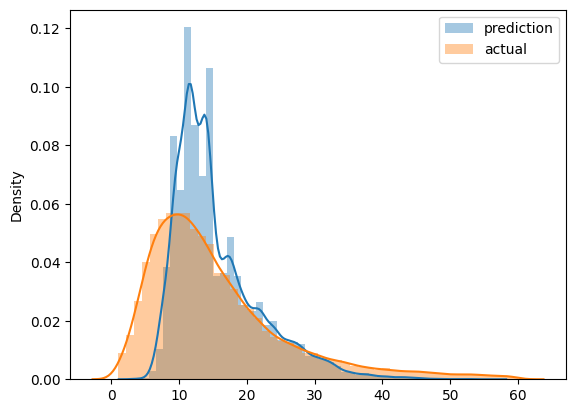

In [16]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend();

#### modelling #2 (cleaner)

In [36]:
# data wrangling func
def read_dataframe(filename) -> pd.DataFrame:
    if filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [37]:
# ingest data 
df_train = read_dataframe('./data/green_tripdata_2026-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2026-02.parquet')

# feature engineering | gotten from EDA
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [38]:
# feature selection
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID'] new feature selction
numerical = ['trip_distance']
target = 'duration'


# train and val set data prep
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

y_train = df_train[target].values
y_val = df_val[target].values

In [40]:
# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_val)

# eval
root_mean_squared_error(y_val, y_pred)

7.108780323539422

In [ ]:
# dump model
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [ ]:
# try a different model
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.105442824302282

#### Implementing MLflow for experiment tracking

In [42]:
X_train.astype("int32")

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 76176 stored elements and shape (38088, 5167)>

In [45]:
with mlflow.start_run():
    
    mlflow.set_tag('developer', 'willcodes')

    # log train and val data paths as params
    mlflow.log_param('train-data-path', './data/green_tripdata_2026-01.parquet')
    mlflow.log_param('val-data-path', './data/green_tripdata_2026-02.parquet')

    # log hyperparam
    alpha = .01 
    mlflow.log_param('alpha', alpha)

    # model
    lr = Lasso(alpha)
    lr.fit(X_train.astype("int32"), y_train)
    
    # pred
    y_pred = lr.predict(X_val)

    # eval
    rmse = root_mean_squared_error(y_val, y_pred)

    # log eval metric
    mlflow.log_metric('rmse', rmse)
    

##### Using Xgboost + hyperopt for trials

In [8]:
train = xgb.DMatrix(X_train, y_train)
val = xgb.DMatrix(X_val, y_val)


def objective(params):
    with mlflow.start_run():

        # init some mlflow oversight
        mlflow.set_tag('model', 'xgboost')
        mlflow.log_params(params) # track params

        # train
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(val, 'validation')],
            early_stopping_rounds=50,
            # n_jobs=8
        )
        
        # pred
        y_pred = booster.predict(val)
        
        # eval
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric('rmse', rmse)

        del booster # to free up space for codespace environment
        gc.collect()

    return {'loss': rmse, 'status': STATUS_OK}



search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed':42
}

trials = Trials()

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials
)



  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [22:51:50] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.16502                           
[1]	validation-rmse:8.26457                           
[2]	validation-rmse:7.60874                           
[3]	validation-rmse:7.13633                           
[4]	validation-rmse:6.80532                           
[5]	validation-rmse:6.57443                           
[6]	validation-rmse:6.41811                           
[7]	validation-rmse:6.31089                           
[8]	validation-rmse:6.23516                           
[9]	validation-rmse:6.18509                           
[10]	validation-rmse:6.15093                          
[11]	validation-rmse:6.12659                          
[12]	validation-rmse:6.11123                          
[13]	validation-rmse:6.10185                          
[14]	validation-rmse:6.09514                          
[15]	validation-rmse:6.08897                          
[16]	validation-rmse:6.08514                          
[17]	validation-rmse:6.08128                          
[18]	valid

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [22:52:19] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.06091                                                    
[1]	validation-rmse:6.97844                                                    
[2]	validation-rmse:6.50687                                                    
[3]	validation-rmse:6.29305                                                    
[4]	validation-rmse:6.20280                                                    
[5]	validation-rmse:6.15988                                                    
[6]	validation-rmse:6.13838                                                    
[7]	validation-rmse:6.13036                                                    
[8]	validation-rmse:6.12626                                                    
[9]	validation-rmse:6.12365                                                    
[10]	validation-rmse:6.11883                                                   
[11]	validation-rmse:6.11877                                                   
[12]	validation-rmse:6.11899            

...

[3]	validation-rmse:6.67908                                                     
[4]	validation-rmse:6.48962                                                     
[5]	validation-rmse:6.38516                                                     
[6]	validation-rmse:6.32324                                                     
[7]	validation-rmse:6.28871                                                     
[8]	validation-rmse:6.25748                                                     
[9]	validation-rmse:6.24344                                                     
[10]	validation-rmse:6.23153                                                    
[11]	validation-rmse:6.22568                                                    
[12]	validation-rmse:6.21981                                                    
[13]	validation-rmse:6.21773                                                    
[14]	validation-rmse:6.21531                                                    
[15]	validation-rmse:6.21275

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [23:11:39] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.13780                                                     
[1]	validation-rmse:8.23209                                                     
[2]	validation-rmse:7.58076                                                     
[3]	validation-rmse:7.12250                                                     
[4]	validation-rmse:6.80044                                                     
[5]	validation-rmse:6.58078                                                     
[6]	validation-rmse:6.42838                                                     
[7]	validation-rmse:6.32268                                                     
[8]	validation-rmse:6.25479                                                     
[9]	validation-rmse:6.20332                                                     
[10]	validation-rmse:6.16541                                                    
[11]	validation-rmse:6.14125                                                    
[12]	validation-rmse:6.12081

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [23:12:01] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[7]	validation-rmse:6.33095                                                     
[8]	validation-rmse:6.29400                                                     
[9]	validation-rmse:6.27260                                                     
[10]	validation-rmse:6.25928                                                    
[11]	validation-rmse:6.24828                                                    
[12]	validation-rmse:6.23915                                                    
[13]	validation-rmse:6.23197                                                    
[14]	validation-rmse:6.22993                                                    
[15]	validation-rmse:6.22512                                                    
[16]	validation-rmse:6.22068                                                    
[17]	validation-rmse:6.21760                                                    
[18]	validation-rmse:6.21572                                                    
[19]	validation-rmse:6.21108

#### Logging Models

##### logging the best model with Autolog

In [ ]:

# get best hyperparams
best_params = space_eval(search_space, best_result)


with mlflow.start_run():

    # train the model with best hyperparams and log with mlflow
    mlflow.xgboost.autolog()

    train = xgb.DMatrix(X_train, y_train)
    val = xgb.DMatrix(X_val, y_val)

    best_model = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(val, 'validation')],
        early_stopping_rounds=50
    )


    del best_model
    gc.collect()


/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [23:12:33] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:8.66214
[1]	validation-rmse:7.62542
[2]	validation-rmse:7.02586
[3]	validation-rmse:6.67908
[4]	validation-rmse:6.48962
[5]	validation-rmse:6.38516
[6]	validation-rmse:6.32324
[7]	validation-rmse:6.28871
[8]	validation-rmse:6.25748
[9]	validation-rmse:6.24344
[10]	validation-rmse:6.23153
[11]	validation-rmse:6.22568
[12]	validation-rmse:6.21981
[13]	validation-rmse:6.21773
[14]	validation-rmse:6.21531
[15]	validation-rmse:6.21275
[16]	validation-rmse:6.20937
[17]	validation-rmse:6.20821
[18]	validation-rmse:6.20582
[19]	validation-rmse:6.20493
[20]	validation-rmse:6.20343
[21]	validation-rmse:6.20283
[22]	validation-rmse:6.19850
[23]	validation-rmse:6.19555
[24]	validation-rmse:6.19234
[25]	validation-rmse:6.19052
[26]	validation-rmse:6.18895
[27]	validation-rmse:6.18681
[28]	validation-rmse:6.18495
[29]	validation-rmse:6.18208
[30]	validation-rmse:6.17976
[31]	validation-rmse:6.17922
[32]	validation-rmse:6.17850
[33]	validation-rmse:6.17559
[34]	validation-rmse:6.1

2026/08/10 23:13:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


72

##### logging the best model with the framework.log_model func

In [12]:
# get best hyperparams
best_params = space_eval(search_space, best_result)

# train the model with best hyperparams and log with mlflow
mlflow.xgboost.autolog(disable=True)


with mlflow.start_run():

    train = xgb.DMatrix(X_train, y_train)
    val = xgb.DMatrix(X_val, y_val)

    best_model = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(val, 'validation')],
        early_stopping_rounds=50
    )

    mlflow.log_params(best_params)

    y_pred = best_model.predict(val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric('rmse', rmse)


    with open('models/preprocessor.b', 'wb') as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact('models/preprocessor.b', artifact_path='preprocessor')

    mlflow.xgboost.log_model(best_model, artifact_path='models_mlflow')

    del best_model
    gc.collect()


[0]	validation-rmse:8.66214
[1]	validation-rmse:7.62542
[2]	validation-rmse:7.02586
[3]	validation-rmse:6.67908
[4]	validation-rmse:6.48962
[5]	validation-rmse:6.38516
[6]	validation-rmse:6.32324


/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [23:52:02] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[7]	validation-rmse:6.28871
[8]	validation-rmse:6.25748
[9]	validation-rmse:6.24344
[10]	validation-rmse:6.23153
[11]	validation-rmse:6.22568
[12]	validation-rmse:6.21981
[13]	validation-rmse:6.21773
[14]	validation-rmse:6.21531
[15]	validation-rmse:6.21275
[16]	validation-rmse:6.20937
[17]	validation-rmse:6.20821
[18]	validation-rmse:6.20582
[19]	validation-rmse:6.20493
[20]	validation-rmse:6.20343
[21]	validation-rmse:6.20283
[22]	validation-rmse:6.19850
[23]	validation-rmse:6.19555
[24]	validation-rmse:6.19234
[25]	validation-rmse:6.19052
[26]	validation-rmse:6.18895
[27]	validation-rmse:6.18681
[28]	validation-rmse:6.18495
[29]	validation-rmse:6.18208
[30]	validation-rmse:6.17976
[31]	validation-rmse:6.17922
[32]	validation-rmse:6.17850
[33]	validation-rmse:6.17559
[34]	validation-rmse:6.17365
[35]	validation-rmse:6.16848
[36]	validation-rmse:6.16674
[37]	validation-rmse:6.16347
[38]	validation-rmse:6.16223
[39]	validation-rmse:6.16149
[40]	validation-rmse:6.15963
[41]	validation-r

2026/08/10 23:52:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


##### logging all the models trained from during multiple expirment runs

In [47]:
# n/b: this could be expensive computationally

train = xgb.DMatrix(X_train, y_train)
val = xgb.DMatrix(X_val, y_val)


def objective(params):
    with mlflow.start_run():

        # init some mlflow oversight
        mlflow.set_tag('model', 'xgboost')
        mlflow.log_params(params) # track params

        # train
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(val, 'validation')],
            early_stopping_rounds=50,
            # n_jobs=8
        )
        
        # pred
        y_pred = booster.predict(val)
        
        # eval
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric('rmse', rmse)

        # log model
        mlflow.xgboost.log_model(booster, artifact_path='xgbmodel')

        del booster # to free up space for codespace environment
        gc.collect()

    return {'loss': rmse, 'status': STATUS_OK}



search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed':42
}


# use hyperopt to search for best hyperparam

trials = Trials()

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials
)



  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [14:30:57] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:6.45385                           
[1]	validation-rmse:6.16849                           
[2]	validation-rmse:6.15092                           
[3]	validation-rmse:6.13924                           
[4]	validation-rmse:6.13381                           
[5]	validation-rmse:6.13321                           
[6]	validation-rmse:6.13085                           
[7]	validation-rmse:6.13581                           
[8]	validation-rmse:6.13696                           
[9]	validation-rmse:6.13786                           
[10]	validation-rmse:6.14064                          
[11]	validation-rmse:6.14072                          
[12]	validation-rmse:6.14609                          
[13]	validation-rmse:6.14686                          
[14]	validation-rmse:6.14996                          
[15]	validation-rmse:6.15011                          
[16]	validation-rmse:6.15173                          
[17]	validation-rmse:6.15407                          
[18]	valid

2026/08/13 14:31:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  3%|▎         | 1/30 [00:27<13:03, 27.01s/trial, best loss: 6.229093651893068]

...

 97%|█████████▋| 29/30 [20:12<00:56, 56.71s/trial, best loss: 5.989440749261179]

/Users/ikwang/miniconda3/envs/rideduration/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [14:51:09] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.77995                                                     
[1]	validation-rmse:9.26017                                                     
[2]	validation-rmse:8.80730                                                     
[3]	validation-rmse:8.41167                                                     
[4]	validation-rmse:8.07005                                                     
[5]	validation-rmse:7.77290                                                     
[6]	validation-rmse:7.51883                                                     
[7]	validation-rmse:7.29915                                                     
[8]	validation-rmse:7.11064                                                     
[9]	validation-rmse:6.95168                                                     
[10]	validation-rmse:6.81575                                                    
[11]	validation-rmse:6.70045                                                    
[12]	validation-rmse:6.60210

2026/08/13 14:52:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



100%|██████████| 30/30 [21:16<00:00, 42.56s/trial, best loss: 5.989440749261179]


#### Interacting with the MLFlow server using the client

In [1]:
from mlflow.tracking import MlflowClient

In [4]:
MLFLOW_TRACKING_URI = 'sqlite:///mlflow.db'

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)



In [5]:
# list experiments
client.search_experiments()

[<Experiment: artifact_location='/Users/ikwang/Documents/Projects/learning-MLOps/mlops-zoomcamp/mlruns/2', creation_time=1786416581956, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1786416581956, lifecycle_stage='active', name='ride-duration-prediction-xgboost', tags={}, trace_location=None, workspace='default'>,
 <Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1781818020103, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1781818020103, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>]

In [ ]:
# search runs
